<a href="https://colab.research.google.com/github/JamesSembukuttiarachchi/rain_in_australia/blob/main/Decision_Tree_for_Australian_Weather_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RainTomorrow Prediction using Decision Tree
## Objective
Predict whether it will rain tomorrow (RainTomorrow) using the Australia weather dataset.
## Why this model?
A decision tree can model non-linear rules and is easy to explain in presentations. It is useful for showing how weather thresholds lead to 'rain' or 'no rain' decisions.

## Workflow covered in this notebook


1.   Load and inspect the dataset
2.   Clean the target and handle missing values
3.   Engineer simple date-based features
4.   Build a preprocessing + modeling pipeline
5.   Train/test split with stratification
6.   Train the model
7.   Evaluate with accuracy, precision, recall, F1, ROC-AUC, confusion matrix
8.   Inspect the most important patterns/features where appropriate
## Notes
This assignment explicitly requires **supervised learning with four distinct algorithms** and states that **deep learning models should not be used.**
This notebook is designed to be run independently.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier

DATA_PATH = "weatherAUS_balanced.csv"   # keep the CSV in the same folder as this notebook, or update this path

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

dataset = pd.read_csv(DATA_PATH)
print("Shape:", dataset.shape)
print("Columns:", list(dataset.columns))
dataset.head()
dataset.info()

Shape: (220632, 23)
Columns: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220632 entries, 0 to 220631
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           220632 non-null  object 
 1   Location       220632 non-null  object 
 2   MinTemp        219550 non-null  float64
 3   MaxTemp        220161 non-null  float64
 4   Rainfall       217508 non-null  float64
 5   Evaporation    125221 non-null  float64
 6   Sunshine       115801 non-null  float64
 7   WindGustDir    205141 non-null  object 
 8   WindGustSpeed  205278 non-null  float64
 9   WindDir9am     205904 non-null  object 
 10  WindDi

In [3]:
# 1. Basic target cleaning
dataset = dataset.copy()
# handles both string and already numeric cases
if dataset["RainTomorrow"].dtype == object:
    dataset["RainTomorrow"] = dataset["RainTomorrow"].astype(str).str.strip().map({"No": 0, "Yes": 1})
    dataset["RainToday"]    = dataset["RainToday"].astype(str).str.strip().map({"No": 0, "Yes": 1})

# Drop rows with missing target (after encoding)
dataset = dataset.dropna(subset=["RainTomorrow"]).reset_index(drop=True)
dataset["RainTomorrow"] = dataset["RainTomorrow"].astype(int)

print("Dataset shape:", dataset.shape)

# 2. Date feature engineering
dataset["Date"] = pd.to_datetime(dataset["Date"], errors="coerce")

dataset["Year"] = dataset["Date"].dt.year
dataset["Month"] = dataset["Date"].dt.month
dataset["Day"] = dataset["Date"].dt.day
dataset["DayOfYear"] = dataset["Date"].dt.dayofyear

# Drop the raw date column after feature extraction
dataset = dataset.drop(columns=["Date"])
print("Cleaned shape:", dataset.shape)

print("Cleaned shape:", dataset.shape)
print("\nTarget distribution:")
print(dataset["RainTomorrow"].value_counts())
print("\nTarget proportions:")
print(dataset["RainTomorrow"].value_counts(normalize=True).round(4))

# 3. Impute missing values (numeric - median, categorical - one hot/drop columns with missing values)
missing_pct = (dataset.isna().mean() * 100).sort_values(ascending=False)
print("\nTop missing columns (%):")
print(missing_pct.head(10).round(2))

# Drop high-missing columns
drop_columns = ['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm']
for col in drop_columns:
    if col in dataset.columns:
        dataset.drop(columns=col, inplace=True)

# Impute numeric columns with median
num_cols = dataset.select_dtypes(include=["float64", "int64"]).columns.tolist()
dataset[num_cols] = dataset[num_cols].fillna(dataset[num_cols].median())

# 4. Encode rest categorical columns
cat_cols = dataset.select_dtypes(include="object").columns.tolist()
print(f"\nCategorical columns to encode: {cat_cols}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    dataset[col] = le.fit_transform(dataset[col].astype(str))
    le_dict[col] = le

print("Cleaned shape:", dataset.shape)

Dataset shape: (220632, 23)
Cleaned shape: (220632, 26)
Cleaned shape: (220632, 26)

Target distribution:
RainTomorrow
0    110316
1    110316
Name: count, dtype: int64

Target proportions:
RainTomorrow
0    0.5
1    0.5
Name: proportion, dtype: float64

Top missing columns (%):
Sunshine         47.51
Evaporation      43.24
Cloud3pm         38.80
Cloud9am         36.87
Pressure3pm       9.86
Pressure9am       9.85
WindGustDir       7.02
WindGustSpeed     6.96
WindDir9am        6.68
WindDir3pm        2.92
dtype: float64

Categorical columns to encode: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
Cleaned shape: (220632, 22)


In [4]:
# Final safety check before splitting
print("\nSafety Check")
print("NaN in target:  ", dataset["RainTomorrow"].isna().sum())
print("NaN in features:", dataset.drop("RainTomorrow", axis=1).isna().sum().sum())


Safety Check
NaN in target:   0
NaN in features: 0


### Split into Train and Test

In [5]:
X = dataset.drop(columns = ["RainTomorrow"])
y = dataset["RainTomorrow"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (176505, 21)
Test shape: (44127, 21)


### Train Decision Tree

In [6]:
model = DecisionTreeClassifier(
    max_depth = 10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)
print("Decision tree trained!!")

Decision tree trained!!


### Predictions

In [7]:
# Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print(f"y_pred: {y_pred}")
print(f"y_pred_prob: {y_pred_prob}")

y_pred: [0 1 0 ... 1 1 0]
y_pred_prob: [0.44953848 0.74377008 0.09047067 ... 0.97959161 0.51942722 0.01642817]


### Evaluate


Metrics Report:

Metrics saved as decision_tree_metrics.csv
        Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Decision Tree     0.787     0.7863  0.7882    0.7873   0.8701

Confusion Matrix:



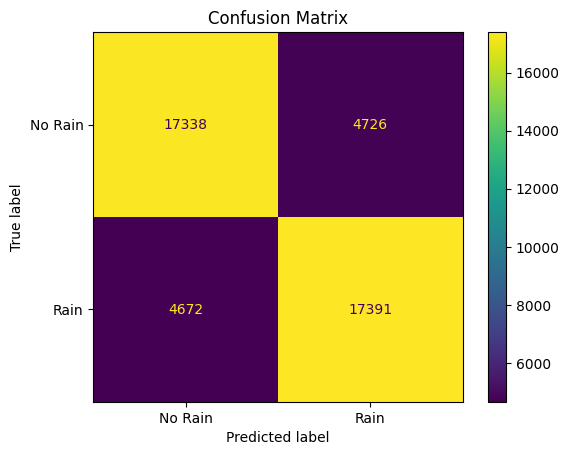


Classification Report:

              precision    recall  f1-score   support

           0     0.7877    0.7858    0.7868     22064
           1     0.7863    0.7882    0.7873     22063

    accuracy                         0.7870     44127
   macro avg     0.7870    0.7870    0.7870     44127
weighted avg     0.7870    0.7870    0.7870     44127



In [8]:
# m1. Basic Metrics
print("\nMetrics Report:\n")
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

metrics = {
    "Model"    : "Decision Tree",
    "Accuracy" : round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall"   : round(recall, 4),
    "F1-Score" : round(f1, 4),
    "ROC-AUC"  : round(roc_auc, 4),
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv("decision_tree_metrics.csv", index=False)

print("Metrics saved as decision_tree_metrics.csv")
print(metrics_df.to_string(index=False))

# m2. Confusion Matrix
print("\nConfusion Matrix:\n")
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Rain", "Rain"])
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

# m3. Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

### Visualization plots

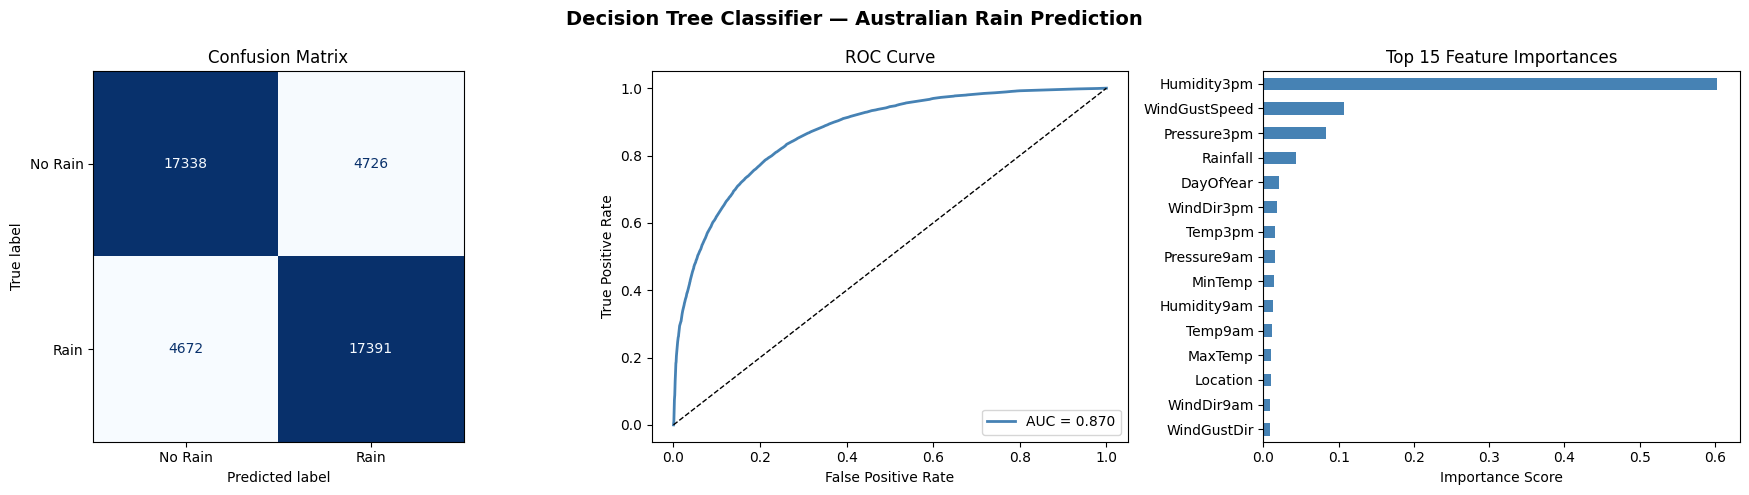


Plot saved as decision_tree_results.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Decision Tree Classifier — Australian Rain Prediction", fontsize=14, fontweight="bold")

# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Rain", "Rain"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

importances = pd.Series(model.feature_importances_, index=X.columns)
top15 = importances.nlargest(15)
top15.sort_values().plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Top 15 Feature Importances")
axes[2].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("decision_tree_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved as decision_tree_results.png")

### Model-specific interpretation

          feature  importance
11    Humidity3pm    0.602814
5   WindGustSpeed    0.106868
13    Pressure3pm    0.083005
3        Rainfall    0.043578
20      DayOfYear    0.020901
7      WindDir3pm    0.017990
15        Temp3pm    0.015737
12    Pressure9am    0.014822
1         MinTemp    0.014092
10    Humidity9am    0.012728
14        Temp9am    0.011468
2         MaxTemp    0.010620
0        Location    0.009599
6      WindDir9am    0.009068
4     WindGustDir    0.008307
9    WindSpeed3pm    0.007852
19            Day    0.003985
8    WindSpeed9am    0.003286
17           Year    0.002444
18          Month    0.000656


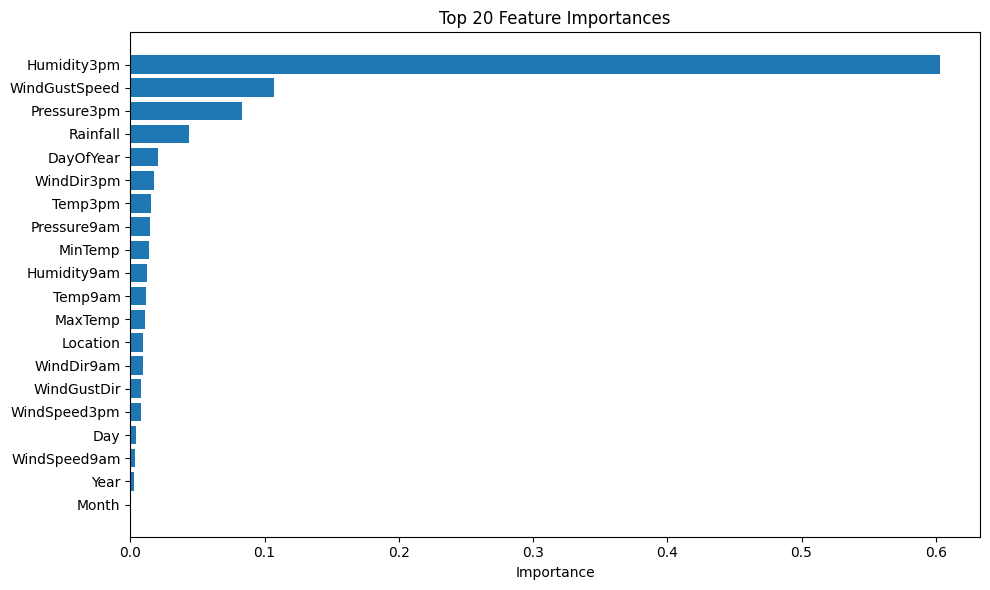

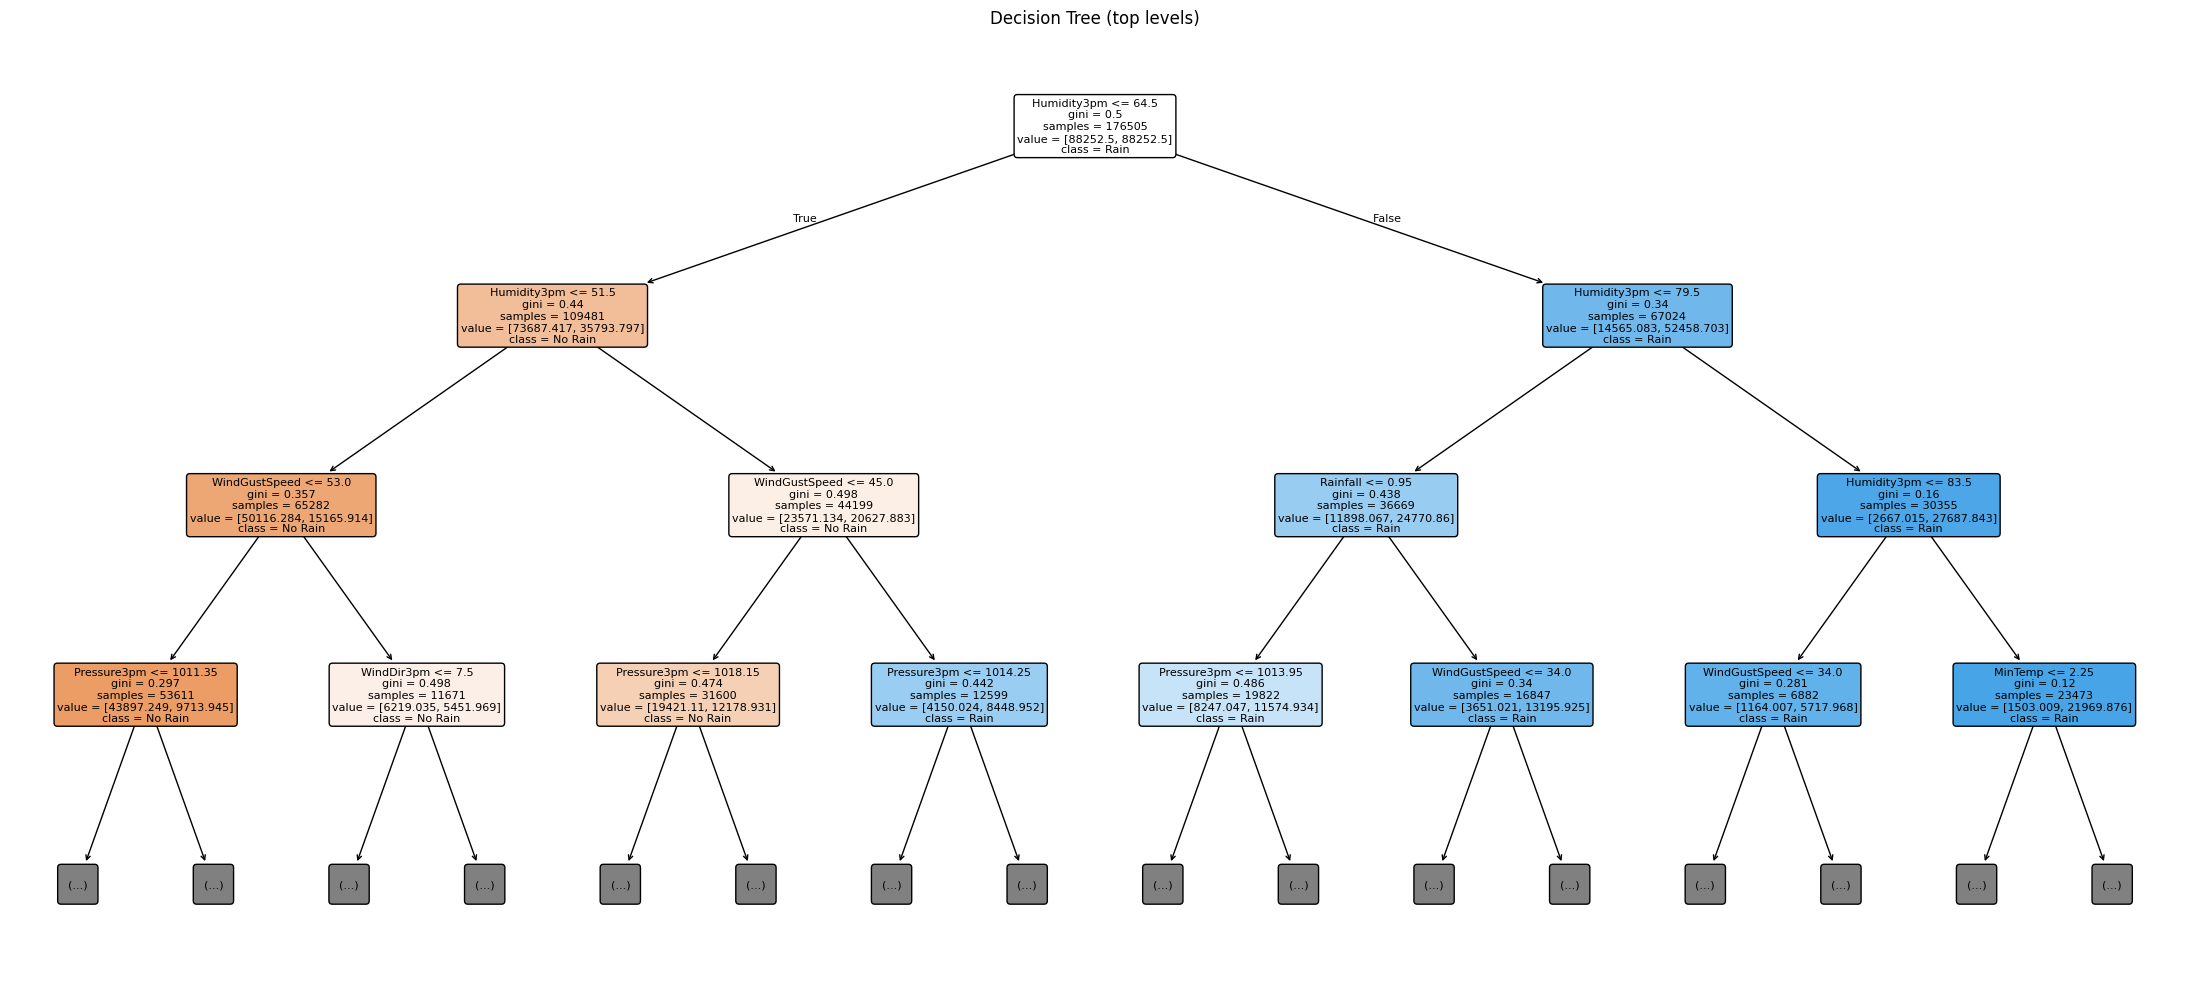

Tree diagram saved → decision_tree_structure.png


In [10]:
# Feature importance (tree-based models)
importance_df = (
    pd.DataFrame({"feature": X.columns, "importance": model.feature_importances_})
      .sort_values("importance", ascending=False)
      .head(20)
)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Decision Tree
plt.figure(figsize=(22, 10))
plot_tree(
    model,
    max_depth=3,
    feature_names=X.columns,
    class_names=["No Rain", "Rain"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree (top levels)")
plt.tight_layout()
plt.savefig("decision_tree_structure.png", dpi=120, bbox_inches="tight")
plt.show()
print("Tree diagram saved → decision_tree_structure.png")

## Short explanation of how Decision Tree works
Decision Tree splits the data using the most informative feature thresholds.
Creates a hierarchy of if/else decisions.
Each leaf node produces the final class prediction.

**How it learns:**
- Starts at the root node with the full dataset
- At each node, splits data on the feature that best separates Rain vs No Rain (using Gini impurity)
- Repeats recursively until a stopping condition is met (`max_depth=10`)

**How it predicts:**
- A new sample travels down the tree following the learned rules
- Reaches a leaf node which outputs the final class — Rain or No Rain